### **Experiment No: 10**


### **One-Way ANOVA**

The one-way ANOVA tests whether the mean of some numeric variable differs across the levels of one categorical variable. It essentially answers the question: do any of the group means differ from one another? We won't get into the details of carrying out an ANOVA by hand as it involves more calculations than the t-test, but the process is similar: you go through several calculations to arrive at a test statistic and then you compare the test statistic to a critical value based on a probability distribution. In the case of the ANOVA, you use the "f-distribution".

The scipy library has a function for carrying out one-way ANOVA tests called scipy.stats.f_oneway(). Let's generate some fake voter age and demographic data and use the ANOVA to compare average ages across the groups:


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
np.random.seed(12)

races =   ["asian","black","hispanic","other","white"]

# Generate random data
voter_race = np.random.choice(a= races,
                              p = [0.05, 0.15 ,0.25, 0.05, 0.5],
                              size=1000)

voter_age = stats.poisson.rvs(loc=18,
                              mu=30,
                              size=1000)

# Group age data by race
voter_frame = pd.DataFrame({"race":voter_race,"age":voter_age})
groups = voter_frame.groupby("race").groups

# Etract individual groups
asian = voter_age[groups["asian"]]
black = voter_age[groups["black"]]
hispanic = voter_age[groups["hispanic"]]
other = voter_age[groups["other"]]
white = voter_age[groups["white"]]

# Perform the ANOVA
stats.f_oneway(asian, black, hispanic, other, white)



F_onewayResult(statistic=np.float64(1.7744689357329695), pvalue=np.float64(0.13173183201930463))

The test output yields an F-statistic of 1.774 and a p-value of 0.1317, indicating that there is no significant difference between the means of each group.

Another way to carry out an ANOVA test is to use the statsmodels library, which allows you to specify a model with a formula syntax that mirrors that used by the R programming language. R users may find this method more familiar:

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('age ~ race',                 # Model formula
            data = voter_frame).fit()

anova_result = sm.stats.anova_lm(model, typ=2)
print (anova_result)


             sum_sq     df         F    PR(>F)
race        199.369    4.0  1.774469  0.131732
Residual  27948.102  995.0       NaN       NaN



As you can see, the statsmodels method produced the same F statistic and P-value (listed as PR(<F)) as the stats.f_oneway method.

Now let's make new age data where the group means do differ and run a second ANOVA:


In [ ]:
np.random.seed(12)

# Generate random data
voter_race = np.random.choice(a= races,
                              p = [0.05, 0.15 ,0.25, 0.05, 0.5],
                              size=1000)

# Use a different distribution for white ages
white_ages = stats.poisson.rvs(loc=18,
                              mu=32,
                              size=1000)

voter_age = stats.poisson.rvs(loc=18,
                              mu=30,
                              size=1000)

voter_age = np.where(voter_race=="white", white_ages, voter_age)

# Group age data by race
voter_frame = pd.DataFrame({"race":voter_race,"age":voter_age})
groups = voter_frame.groupby("race").groups

# Extract individual groups
asian = voter_age[groups["asian"]]
black = voter_age[groups["black"]]
hispanic = voter_age[groups["hispanic"]]
other = voter_age[groups["other"]]
white = voter_age[groups["white"]]

# Perform the ANOVA
stats.f_oneway(asian, black, hispanic, other, white)


F_onewayResult(statistic=np.float64(10.164699828386366), pvalue=np.float64(4.5613242113994585e-08))

In [ ]:
# Alternate method
model = ols('age ~ race',                 # Model formula
            data = voter_frame).fit()

anova_result = sm.stats.anova_lm(model, typ=2)
print (anova_result)

                sum_sq     df        F        PR(>F)
race       1284.123213    4.0  10.1647  4.561324e-08
Residual  31424.995787  995.0      NaN           NaN


The test result suggests the groups don't have the same sample means in this case, since the p-value is significant at a 99% confidence level. We know that it is the white voters who differ because we set it up that way in the code, but when testing real data, you may not know which group(s) caused the test to throw a positive result. To check which groups differ after getting a positive ANOVA result, you can perform a follow up test or "post-hoc test".

One post-hoc test is to perform a separate t-test for each pair of groups. You can perform a t-test between all pairs using by running each pair through the stats.ttest_ind() we covered in the lesson on t-tests:

In [ ]:
# Get all race pairs
race_pairs = []

for race1 in range(4):
    for race2  in range(race1+1,5):
        race_pairs.append((races[race1], races[race2]))

# Conduct t-test on each pair
for race1, race2 in race_pairs:
    print(race1, race2)
    print(stats.ttest_ind(voter_age[groups[race1]],
                          voter_age[groups[race2]]))


asian black
TtestResult(statistic=np.float64(0.8386446909747979), pvalue=np.float64(0.4027281369339345), df=np.float64(189.0))
asian hispanic
TtestResult(statistic=np.float64(-0.42594691924932293), pvalue=np.float64(0.6704669004240726), df=np.float64(286.0))
asian other
TtestResult(statistic=np.float64(0.9795284739636), pvalue=np.float64(0.3298877500095151), df=np.float64(92.0))
asian white
TtestResult(statistic=np.float64(-2.318108811252288), pvalue=np.float64(0.020804701566400217), df=np.float64(557.0))
black hispanic
TtestResult(statistic=np.float64(-1.9527839210712925), pvalue=np.float64(0.05156197171952594), df=np.float64(389.0))
black other
TtestResult(statistic=np.float64(0.28025754367057176), pvalue=np.float64(0.7795770111117659), df=np.float64(195.0))
black white
TtestResult(statistic=np.float64(-5.379303881281834), pvalue=np.float64(1.0394212166624012e-07), df=np.float64(660.0))
hispanic other
TtestResult(statistic=np.float64(1.5853626170340225), pvalue=np.float64(0.113966305

The p-values for each pairwise t-test suggest mean of white voters is likely different from the other groups, since the p-values for each t-test involving the white group is below 0.05. Using unadjusted pairwise t-tests can overestimate significance, however, because the more comparisons you make, the more likely you are to come across an unlikely result due to chance. We can adjust for this multiple comparison problem by dividing the statistical significance level by the number of comparisons made. In this case, if we were looking for a significance level of 5%, we'd be looking for p-values of 0.05/10 = 0.005 or less. This simple adjustment for multiple comparisons is known as the Bonferroni correction.

The Bonferroni correction is a conservative approach to account for the multiple comparisons problem that may end up rejecting results that are actually significant. Another common post hoc-test is Tukey's test. You can carry out Tukey's test using the pairwise_tukeyhsd() function in the statsmodels.stats.multicomp library:

group1,group2,meandiff,p-adj,lower,upper,reject
asian,black,-0.8032,0.9208,-3.4423,1.836,False
asian,hispanic,0.4143,0.9915,-2.1011,2.9297,False
asian,other,-1.0645,0.8906,-4.2391,2.11,False
asian,white,1.9547,0.1751,-0.4575,4.3668,False
black,hispanic,1.2175,0.2318,-0.386,2.821,False
black,other,-0.2614,0.9986,-2.7757,2.253,False
black,white,2.7579,0.0,1.3217,4.194,True
hispanic,other,-1.4789,0.4374,-3.863,0.9053,False
hispanic,white,1.5404,0.004,0.3468,2.734,True
other,white,3.0192,0.0028,0.7443,5.2941,True


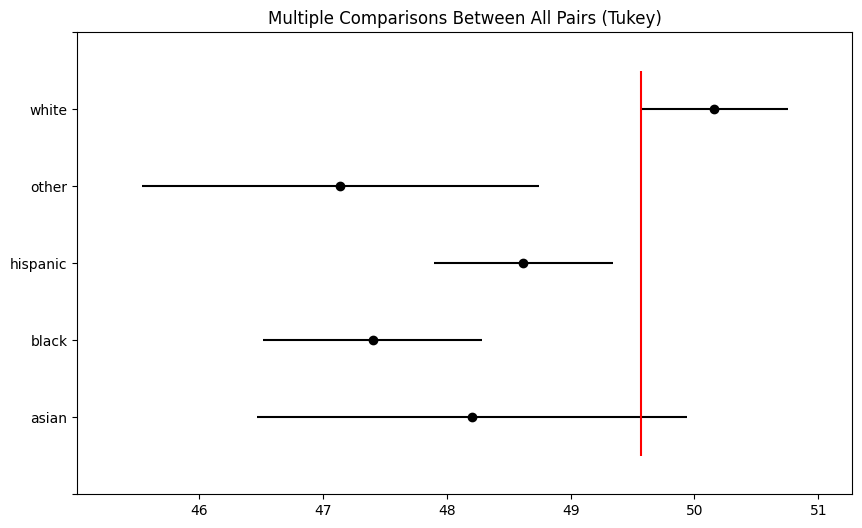

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=voter_age,     # Data
                          groups=voter_race,   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
plt.vlines(x=49.57,ymin=-0.5,ymax=4.5, color="red")

tukey.summary()              # See test summary

The output of the Tukey test shows the average difference, a confidence interval as well as whether you should reject the null hypothesis for each pair of groups at the given significance level. In this case, the test suggests we reject the null hypothesis for 3 pairs, with each pair including the "white" category. This suggests the white group is likely different from the others. The 95% confidence interval plot reinforces the results visually: only 1 other group's confidence interval overlaps the white group's confidence interval.

### **Questions**

**1. Explain input and output characteristics for f_oneway function from stats library**

The scipy.stats.f_oneway() function is used to perform a one-way ANOVA test.

Input Characteristics:

  * It takes two or more independent sample groups as input. Each group should be provided as a separate array-like object (e.g., NumPy arrays or lists). These arrays contain the numerical data for each group you want to compare.

Output Characteristics:

  * The function returns an object of type F_onewayResult, which has two main attributes:
        statistic: This is the calculated F-statistic for the ANOVA test. The F-statistic is a ratio of the variance between the group means to the variance within the groups. A larger F-statistic indicates greater differences between group means.
        pvalue: This is the p-value associated with the F-statistic. The p-value indicates the probability of observing an F-statistic as extreme as, or more extreme than, the one calculated, assuming the null hypothesis (that all group means are equal) is true. A small p-value (typically less than 0.05) suggests that there is a statistically significant difference between at least two of the group means.

**2. Explain results of sm.stats.anova_lm fucntion.**

The sm.stats.anova_lm function provides an ANOVA table for a linear model. Based on the anova_result DataFrame, here's what each column represents:

* sum_sq (Sum of Squares): This column represents the variation explained by each factor in the model. For race, it's the sum of squares due to the 'race' variable, indicating how much of the total variation in 'age' can be attributed to differences between racial groups. For Residual, it's the unexplained variation.

* df (Degrees of Freedom): This is the number of independent pieces of information used to calculate the sum of squares. For race, it's the number of groups minus 1 (5 - 1 = 4). For Residual, it's the total number of observations minus the number of parameters estimated.

* F (F-statistic): This is the F-statistic for the test. It's a ratio of the mean square of the factor (race) to the mean square of the residuals. A larger F-statistic indicates that the variation between group means is greater than the variation within groups.

* PR(>F) (p-value): This is the p-value associated with the F-statistic. It indicates the probability of observing an F-statistic as extreme as, or more extreme than, the one calculated, assuming the null hypothesis (that all group means are equal) is true. A small p-value (e.g., less than 0.05) suggests that there is a statistically significant difference between at least two of the group means.

In the anova_result you provided:

                sum_sq     df        F        PR(>F)
race       1284.123213    4.0  10.1647  4.561324e-08
Residual  31424.995787  995.0       NaN           NaN

The race row shows the effects related to the racial groups.
        sum_sq for race is 1284.123213.
        df for race is 4.0.
        The F statistic is 10.1647.
        The PR(>F) (p-value) is 4.561324e-08, which is a very small number (0.0000000456). This p-value is much less than common significance levels like 0.05 or 0.01, indicating that there is a statistically significant difference in the mean ages among the different racial groups.

The Residual row represents the variance not explained by the model.
        sum_sq for residuals is 31424.995787.
        df for residuals is 995.0.
        The F-statistic and p-value are not applicable for residuals directly in this table format.

**3. What role ANOVA plays in data analytics?**

ANOVA (Analysis of Variance) plays a crucial role in data analytics, particularly in inferential statistics, by allowing analysts to compare means of three or more groups simultaneously. Here's a breakdown of its key roles:

* Comparing Group Means: Its primary purpose is to determine if there are statistically significant differences between the means of two or more independent groups. For example, comparing the effectiveness of different marketing strategies, the performance of different product designs, or, as in this notebook, the average age across different demographic groups.

* Identifying Significant Factors: In more complex ANOVA models (like two-way or N-way ANOVA), it can help identify which independent variables (factors) or combinations of factors have a significant impact on a dependent variable. This is vital for understanding relationships within data.

* Reducing Type I Error: If you were to perform multiple pairwise t-tests to compare several groups, the probability of making a Type I error (falsely rejecting a true null hypothesis) would increase with each test. ANOVA performs a single test for overall significance, thereby controlling the Type I error rate across all comparisons.

* Hypothesis Testing: ANOVA is a fundamental tool for hypothesis testing. The null hypothesis for a one-way ANOVA is that all group means are equal, while the alternative hypothesis is that at least one group mean is different from the others. By calculating an F-statistic and a p-value, ANOVA helps in deciding whether to reject or fail to reject the null hypothesis.

* Foundation for Post-Hoc Tests: When ANOVA indicates a significant difference among groups, it doesn't tell you which specific groups differ. This is where post-hoc tests (like Tukey's HSD, as demonstrated) come in. ANOVA sets the stage for these follow-up analyses, guiding further investigation.

* Experimental Design Analysis: It's widely used in analyzing data from experimental designs, helping researchers understand the effects of different treatments or conditions on outcomes.

**4. When to use one way ANOVA? Explain with real world case. **

You should use a one-way ANOVA when you want to compare the means of three or more independent groups to determine if there's a statistically significant difference between them on a single continuous dependent variable.

Here's a real-world case:

Scenario: A pharmaceutical company develops three different formulations of a new pain reliever (Formulation A, Formulation B, and Formulation C). They want to determine if there's a significant difference in the average time to pain relief among the three formulations.

* Dependent Variable (Continuous): Time to pain relief (measured in minutes).
* Independent Variable (Categorical with three or more levels): Pain reliever formulation (Formulation A, Formulation B, Formulation C).

Why One-Way ANOVA is appropriate:

* Comparing Three or More Groups: There are three distinct groups (Formulation A, B, and C) whose means (average pain relief time) need to be compared.
* One Independent Variable: The grouping factor is a single categorical variable (formulation type).
* Continuous Dependent Variable: The outcome being measured (time to pain relief) is continuous.
* Avoiding Type I Errors: If they were to perform multiple t-tests (e.g., A vs. B, A vs. C, B vs. C), the probability of finding a statistically significant difference by chance (Type I error) would increase. ANOVA performs an omnibus test to see if any of the group means differ, controlling this error rate.

Outcome:

* If the one-way ANOVA yields a significant p-value (e.g., p < 0.05), it suggests that there is a statistically significant difference in the average time to pain relief among at least two of the formulations. It doesn't tell you which specific formulations differ.
* To find out which specific formulations are different, post-hoc tests (like Tukey's HSD) would then be performed.

**5. When to use 2 way ANOVA ? Explain with real world case.**

You should use a two-way ANOVA when you want to examine the effect of two independent categorical variables (factors) on a single continuous dependent variable. It not only assesses the main effect of each independent variable but also the interaction effect between them.

Here's a real-world case:

Scenario: A company manufactures a new type of battery and wants to determine how two factors — material type (e.g., Lithium, Nickel-Cadmium, Alkaline) and operating temperature (e.g., Low, Medium, High) — affect the battery life (measured in hours).

* Dependent Variable (Continuous): Battery life (in hours).
* Independent Variable 1 (Categorical): Material Type (with 3 levels: Lithium, Nickel-Cadmium, Alkaline).
* Independent Variable 2 (Categorical): Operating Temperature (with 3 levels: Low, Medium, High).

Why Two-Way ANOVA is appropriate:

* Multiple Independent Variables: There are two categorical independent variables (Material Type and Operating Temperature) whose effects on battery life are being investigated.
* Interaction Effects: The researchers suspect that the effect of Material Type on battery life might depend on the Operating Temperature, and vice versa. For example, Lithium batteries might perform best at low temperatures, while Nickel-Cadmium might be more robust at high temperatures. A two-way ANOVA can detect such an interaction.
* Efficiency: Instead of conducting separate one-way ANOVAs or multiple t-tests, which would increase the risk of Type I errors and be less efficient, a two-way ANOVA allows for a single, comprehensive analysis of both main effects and their interaction.

Outcome:

* A two-way ANOVA would yield p-values for three effects:
Main effect of Material Type: Is there a significant difference in battery life across different material types, ignoring temperature?
        Main effect of Operating Temperature: Is there a significant difference in battery life across different temperatures, ignoring material type?
        Interaction effect between Material Type and Operating Temperature: Does the effect of one factor on battery life depend on the level of the other factor? (This is often the most interesting finding).
